In [10]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

In [11]:
df = pd.read_csv("../data/processed/ml_delivery_dataset_cleaned.csv")
df.head()

,order_id,delivery_time_days,total_price,total_freight,num_items,avg_product_weight_g,avg_product_length_cm,avg_product_height_cm,avg_product_width_cm,avg_product_volume_cm3,purchase_dayofweek,purchase_month,customer_state,seller_state
0,5e605c248def72c23690c44126f8ecb6,14,39.99,15.10,1,350.0,25.0,8.0,19.0,3800.0,1,2,MG,SP
1,c45067032fd84f4cf408730ff5205568,6,179.80,19.14,1,7400.0,45.0,29.0,53.0,69165.0,3,5,PR,SP
2,8013932c4c00036478bea6424e783117,14,44.90,15.10,1,350.0,20.0,2.0,26.0,1040.0,3,2,RS,SP
3,385afce75f62f7af7587814b87692d2d,11,80.00,12.90,1,1600.0,45.0,15.0,30.0,20250.0,4,2,SP,SP
4,cb7c837f8c5240816176dc115c21a746,13,150.00,88.56,1,4000.0,30.0,35.0,30.0,31500.0,4,6,RN,SP


Учитывая проведенный EDA:

- числовые признаки оставить как есть
- категориальные- OneHot
- выбросы уже обработаны
- корреляции слабые, лучше использовать нелинейные модели

In [12]:
X = df.drop(columns=["delivery_time_days"])
y = df["delivery_time_days"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

C:\Users\d3-l5\AppData\Local\Temp\ipykernel_13292\4253668355.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


In [13]:
# препроцессинг
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [14]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [15]:
pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
df.isnull().sum()

order_id                  0
delivery_time_days        0
total_price               0
total_freight             0
num_items                 0
avg_product_weight_g      0
avg_product_length_cm     0
avg_product_height_cm     0
avg_product_width_cm      0
avg_product_volume_cm3    0
purchase_dayofweek        0
purchase_month            0
customer_state            0
seller_state              0
dtype: int64

In [18]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [19]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4.190761282598511
RMSE: 6.173744336800155


Средняя ошибка предсказания в пределах нескольких дней. Это вполне нормальный результат для задачи, где присутствует сильная вариативность и нелинейность данных.

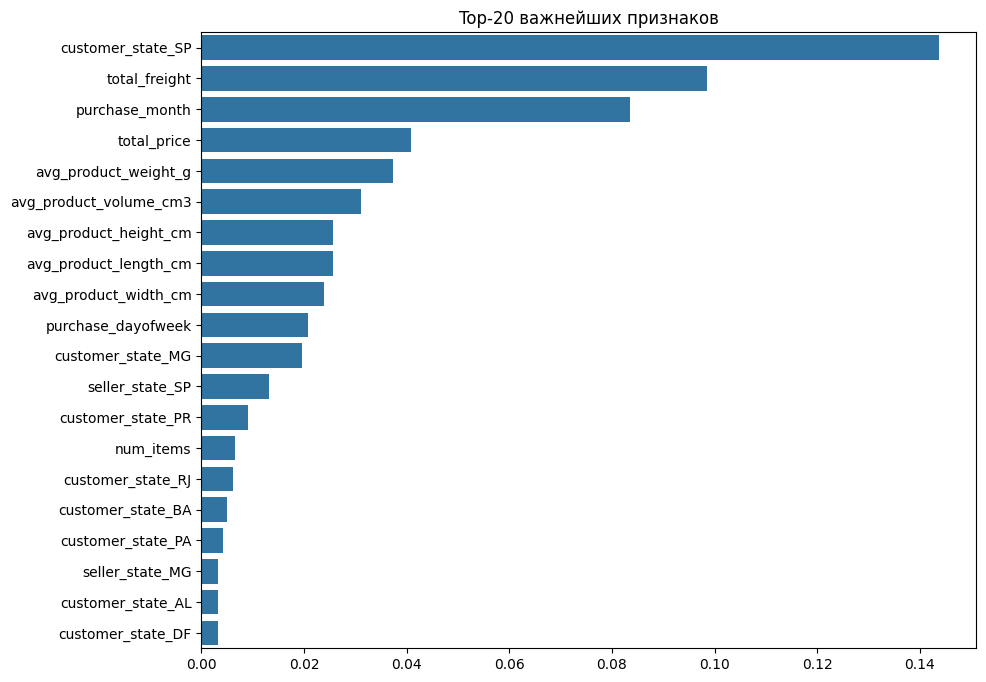

In [20]:
# Важность признаков
model = pipeline.named_steps["model"]
preprocess = pipeline.named_steps["preprocess"]

# Получаем имена OHE признаков
ohe = preprocess.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

# Объединяем все признаки
feature_names = np.concatenate([numeric_features, cat_feature_names])

# Важности
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,8))
sns.barplot(x=importances[indices][:20], y=feature_names[indices][:20])
plt.title("Top-20 важнейших признаков")
plt.show()

Наибольшее влияние на прогноз времени доставки оказывают регион покупателя, особенно штат SP, стоимость доставки и месяц покупки. также заметный вклад вносят цена заказа и физические характеристики товара, что подтверждает важность как географических, так и логистических факторов.

# Вывод

В ходе проекта был построен пайплайн для прогнозирования времени доставки в e-commerce. Данные были очищены от пропусков и аномалий, проанализированы и подготовлены к обучению. Исследование показало отсутствие сильных линейных зависимостей. Модель RandomForest продемонстрировала устойчивые результаты (MAE ≈ 4.2 дня), что является приемлемой точностью для логистической задачи. Анализ важности признаков показал, что ключевую роль играют география покупателей, стоимость доставки и характеристики товаров.